## **Assignment: "The Visual Inspector" — CNN Fundamentals**

**The Scenario**

You have just joined "VisionCore AI" as a Computer Vision Engineer. Your manager hands you a grayscale image classification pipeline that uses a plain MLP — it treats each image as a flat vector and ignores all spatial structure. Your task is to understand *why* CNNs were invented, how their core operations work, and implement the key building blocks from scratch to prove you are ready to rebuild the pipeline the right way.

## **Part 1: Conceptual Questions**

### **Question 1: Why Not Just Use an MLP?**

Your manager asks why the old MLP pipeline struggles with images. Which answer *best* explains the core problem?

A) MLPs cannot use ReLU activations on image data.

B) MLPs flatten the image into a vector, destroying spatial relationships — a pixel and its neighbour are treated no differently from two pixels at opposite corners.

C) MLPs can only process square images.

D) MLPs always overfit because they have too few parameters for image data.

Answer: (B), MLPs flatten the image into a vector, destroying spatial relationships — a pixel and its neighbour are treated no differently from two pixels at opposite corners.

Images have a local relationship in the pixels, that is not taken into account in the standard MLP pipeline.

### **Question 2: Parameter Sharing**

A convolutional layer uses a single 3×3 filter (kernel) and slides it across a 28×28 grayscale image. How many *learnable parameters* does this filter have, and why is this beneficial compared to a fully-connected layer of the same output size?

A) 784 parameters; same as the MLP — no difference.

B) 9 parameters; the same filter detects the same feature (e.g. an edge) everywhere in the image, drastically reducing parameter count and enabling translational equivariance.

C) 9 parameters; but this means the network can only detect 9 different features total.

D) 28 parameters; one per row of the image.

Answer: (B), 9 parameters; the same filter detects the same feature (e.g. an edge) everywhere in the image, drastically reducing parameter count and enabling translational equivariance.

the filter has 9 learnable parameters. This is beneficial because the same kernel is reused across the whole image, so it detects the same feature everywhere while greatly reducing the number of parameters compared to a fully connected layer.

### **Question 3: The Role of Pooling**

After the convolution + ReLU step, you apply 2×2 Max Pooling with stride 2. What are the *two* main effects of this operation?

A) It adds learnable parameters to help the network generalise, and it doubles the spatial resolution.

B) It reduces spatial dimensions (downsampling), and it introduces a degree of translation invariance by retaining only the strongest activation in each region.

C) It normalises pixel values to [0, 1], and it prevents vanishing gradients.

D) It replaces the need for a non-linear activation function.

Answer: (B), It reduces spatial dimensions (downsampling), and it introduces a degree of translation invariance by retaining only the strongest activation in each region.

Max pooling downsamples the feature map by taking the maximum value in each pooling window. This reduces the spatial dimensions, making the network more efficient and less sensitive to small translations of features in the image. By keeping only the strongest activation, pooling helps the network focus on the most important features while discarding noise.

## **Part 2: Numerical Reasoning**

### **Question 4: Output Size Calculation**

You are given the following CNN layer configuration:

| Setting | Value |
|---|---|
| Input size | 32 × 32 (single channel) |
| Conv layer | 16 filters, kernel 5×5, stride 1, padding 0 |
| Pooling | 2×2 Max Pool, stride 2 |

Using the formula $O = \lfloor\frac{I - K + 2P}{S}\rfloor + 1$:

1. What is the spatial size of the **feature map after the Conv layer**?
2. What is the spatial size **after Max Pooling**?
3. If you then flatten and feed into a fully-connected layer with 10 outputs, how many weights does *that* FC layer have?

1. **After Conv layer:**
    - Using formula: $O = \lfloor\frac{I - K + 2P}{S}\rfloor + 1$, Assuming Stride of Conv Layer = 1, and no padding.
    - $O = \lfloor\frac{32 - 5 + 2(0)}{1}\rfloor + 1 = \lfloor\frac{27}{1}\rfloor + 1 = 28$
    - Feature map size: **28 × 28**
    - Number of filters: 16, so output shape: **28 × 28 × 16**

2. **After Max Pooling (2×2, stride 2):**
    - $O = \lfloor\frac{28 - 2 + 0}{2}\rfloor + 1 = \lfloor\frac{26}{2}\rfloor + 1 = 14$, Assuming Stride of Pool Layer = 2 and no padding.
    - Pooled feature map size: **14 × 14**
    - With 16 filters: output shape: **14 × 14 × 16**

3. **Fully-connected layer weights:**
    - Flattened input size: $14 \times 14 \times 16 = 3136$
    - FC layer connects to 10 outputs
    - Number of weights: $3136 \times 10 = \textbf{31,360 weights}$
    - (Plus 10 biases if included)

## **Part 3: Coding Challenge — Build the Core Operations**

In this section you will implement 2D convolution and max pooling from scratch using only NumPy. This mirrors exactly what frameworks like PyTorch do under the hood.

**Fill in the missing lines marked `## FILL IN`.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- A simple 8x8 synthetic 'image' ---
np.random.seed(42)
image = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 0],
    [0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
], dtype=float)

# --- Edge-detection kernel (vertical Sobel) ---
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
], dtype=float)

print("Image shape:", image.shape)
print("Kernel shape:", kernel.shape)

Image shape: (8, 8)
Kernel shape: (3, 3)


In [3]:
def conv2d(image, kernel, stride=1, padding=0):
    """
    Perform a 2D convolution (no bias, single channel).
    Returns the feature map.
    """
    H, W = image.shape
    K = kernel.shape[0]  # square kernel assumed

    # Step 1: Pad the image with zeros if padding > 0
    if padding > 0:
        image = np.pad(image, padding, mode='constant')

    # Step 2: Calculate output size using the formula from Q4
    ## FILL IN: compute out_H and out_W
    out_H = ((H - K + 2*padding) // stride) + 1
    out_W = ((W - K + 2*padding) // stride) + 1

    feature_map = np.zeros((out_H, out_W))

    # Step 3: Slide the kernel across the image
    for i in range(out_H):
        for j in range(out_W):
            # Extract the patch of the image the kernel sits on
            patch = image[i*stride : i*stride + K,
                          j*stride : j*stride + K]
            ## FILL IN: compute the convolution at position (i, j)
            ## Hint: element-wise multiply patch and kernel, then sum
            feature_map[i, j] = np.sum(patch * kernel)

    return feature_map


def relu(x):
    ## FILL IN: apply ReLU (clip negatives to 0)
    return np.maximum(0, x)


# --- Run convolution + ReLU ---
fmap = conv2d(image, kernel, stride=1, padding=0)
fmap_relu = relu(fmap)

print("Feature map shape:", fmap.shape)

Feature map shape: (6, 6)


In [4]:
def max_pool2d(feature_map, pool_size=2, stride=2):
    """
    Perform 2D Max Pooling.
    """
    H, W = feature_map.shape
    out_H = (H - pool_size) // stride + 1
    out_W = (W - pool_size) // stride + 1
    pooled = np.zeros((out_H, out_W))

    for i in range(out_H):
        for j in range(out_W):
            patch = feature_map[i*stride : i*stride + pool_size,
                                j*stride : j*stride + pool_size]
            ## FILL IN: take the maximum value in the patch
            pooled[i, j] = np.max(patch)

    return pooled


# --- Run Max Pooling ---
pooled = max_pool2d(fmap_relu, pool_size=2, stride=2)
print("Pooled feature map shape:", pooled.shape)

Pooled feature map shape: (3, 3)


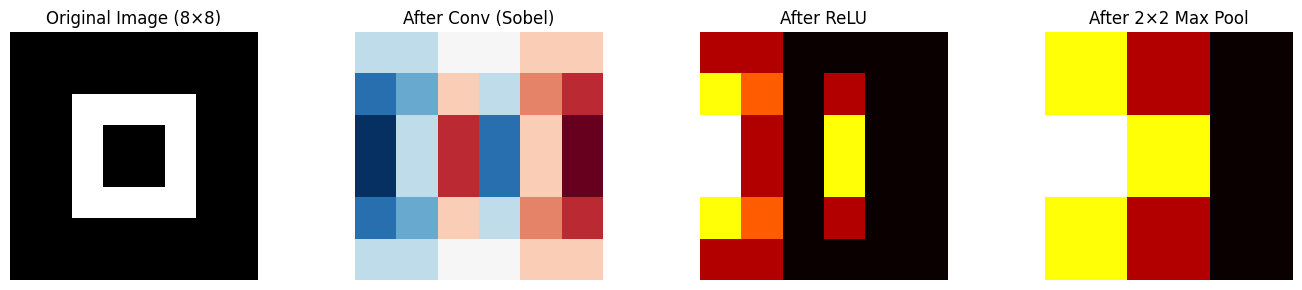

In [ ]:
# --- Visualise the pipeline ---
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image (8×8)')

axes[1].imshow(fmap, cmap='RdBu')
axes[1].set_title('After Conv (Sobel)')

axes[2].imshow(fmap_relu, cmap='hot')
axes[2].set_title('After ReLU')

axes[3].imshow(pooled, cmap='hot')
axes[3].set_title('After 2×2 Max Pool')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

### **Observations**

> Answer the following after running your code:
>
> 1. What does the feature map *after Conv* tell you about the image? Where are the high-magnitude responses, and why?
> 2. What does ReLU remove, and why is that useful here?
> 3. The pooled map is much smaller — does it still capture the essential structure of the original image? What is lost?

...
1. The Sobel kernel is an edge detector. High-magnitude responses occur at the **vertical edges** of the square (left and right boundaries at columns 2–3 and 5–6). Positive values mark right-going edges, negative values mark left-going edges. The interior (columns 3–5) has near-zero response because there is little vertical gradient there — the kernel detects changes in intensity, not flat regions.

2. ReLU removes all **negative values** (sets them to 0). This is useful because:
    - It introduces **non-linearity**, allowing the network to learn complex patterns.
    - Negative responses from edge detection (left-going edges) are discarded; we keep only strong activations that indicate meaningful features.
    - It sparsifies the representation — many activations become exactly zero, reducing noise and computational cost.

3. Yes, the **3×3 pooled map still captures the core structure**: the vertical edges of the square are preserved as a band of high values. However, **fine spatial detail is lost** — the pooling operation averages away precise edge locations within each 2×2 window. We can no longer tell exactly where an edge is (e.g., column 2 or 3), only that edges exist in a region. This trade-off (spatial precision for robustness and efficiency) is why pooling is powerful in CNNs: small translations of the image produce the same pooled output, providing translation invariance.